<a href="https://colab.research.google.com/github/sripavan24/cnn-ann_deep_L/blob/main/rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import nltk
import re
from nltk.corpus import stopwords


In [ ]:
df = pd.read_csv("IMDB Dataset.csv", engine="python", on_bad_lines="skip")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df['review'].iloc[3]

"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."

(21343,)

(21343,)

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:

def text_cleaning(review):

  review1=re.sub("[^a-zA-Z0-9]"," ",review)
  review2=review1.lower()
  review3=review2.split()
  review4=[w for w in review3 if w not in set(stopwords.words('english'))]
  return review4

df['clean_text']=df['review'].apply(text_cleaning)


In [ ]:
df['sentiment']=df['sentiment'].map({'positive':1,"negative":0})

In [ ]:
x=df['clean_text']
y=df['sentiment']


In [ ]:
x[0]

['one',
 'reviewers',
 'mentioned',
 'watching',
 '1',
 'oz',
 'episode',
 'hooked',
 'right',
 'exactly',
 'happened',
 'br',
 'br',
 'first',
 'thing',
 'struck',
 'oz',
 'brutality',
 'unflinching',
 'scenes',
 'violence',
 'set',
 'right',
 'word',
 'go',
 'trust',
 'show',
 'faint',
 'hearted',
 'timid',
 'show',
 'pulls',
 'punches',
 'regards',
 'drugs',
 'sex',
 'violence',
 'hardcore',
 'classic',
 'use',
 'word',
 'br',
 'br',
 'called',
 'oz',
 'nickname',
 'given',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'focuses',
 'mainly',
 'emerald',
 'city',
 'experimental',
 'section',
 'prison',
 'cells',
 'glass',
 'fronts',
 'face',
 'inwards',
 'privacy',
 'high',
 'agenda',
 'em',
 'city',
 'home',
 'many',
 'aryans',
 'muslims',
 'gangstas',
 'latinos',
 'christians',
 'italians',
 'irish',
 'scuffles',
 'death',
 'stares',
 'dodgy',
 'dealings',
 'shady',
 'agreements',
 'never',
 'far',
 'away',
 'br',
 'br',
 'would',
 'say',
 'main',
 'appeal',
 'show'

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_text,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
w2v_model = Word2Vec(
    sentences=x_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
w2v_model.wv.index_to_key

['br',
 'movie',
 'film',
 'one',
 'like',
 'good',
 'time',
 'even',
 'would',
 'story',
 'see',
 'really',
 'well',
 'much',
 'bad',
 'get',
 'people',
 'great',
 'also',
 'first',
 'make',
 'made',
 'way',
 'movies',
 'could',
 'characters',
 'think',
 'character',
 'films',
 'watch',
 'seen',
 'many',
 'two',
 'acting',
 'love',
 'never',
 'plot',
 'best',
 'little',
 'life',
 'know',
 'show',
 'ever',
 'man',
 'better',
 'still',
 'end',
 'scene',
 'say',
 'scenes',
 'something',
 'go',
 'real',
 'back',
 'watching',
 'actors',
 'thing',
 'years',
 'director',
 'though',
 'funny',
 '10',
 'work',
 'nothing',
 'old',
 'actually',
 'another',
 'look',
 'new',
 'makes',
 'find',
 'going',
 'lot',
 'every',
 'part',
 'world',
 'us',
 'quite',
 'horror',
 'pretty',
 'cast',
 'things',
 'want',
 'take',
 'young',
 'seems',
 'long',
 'around',
 'big',
 'however',
 'got',
 'may',
 'thought',
 'fact',
 'enough',
 'must',
 'without',
 'right',
 'comedy',
 'action',
 'music',
 'give',
 'orig

In [ ]:
w2v_model.wv.similar_by_word("least")

[('honestly', 0.7615543603897095),
 ('maybe', 0.74595046043396),
 ('probably', 0.7351728677749634),
 ('otherwise', 0.7251017093658447),
 ('expected', 0.714248538017273),
 ('missed', 0.7096939086914062),
 ('endurable', 0.7063161730766296),
 ('twice', 0.7046435475349426),
 ('personally', 0.7034003138542175),
 ('actually', 0.7006362676620483)]

In [ ]:
w2v_model.wv.most_similar("least")

[('honestly', 0.7615543603897095),
 ('maybe', 0.74595046043396),
 ('probably', 0.7351728677749634),
 ('otherwise', 0.7251017093658447),
 ('expected', 0.714248538017273),
 ('missed', 0.7096939086914062),
 ('endurable', 0.7063161730766296),
 ('twice', 0.7046435475349426),
 ('personally', 0.7034003138542175),
 ('actually', 0.7006362676620483)]

In [ ]:
w2v_model.wv['actually']

array([ 0.30984318,  0.15777047, -0.28359988,  0.2081246 ,  0.08976045,
       -0.5266405 ,  0.90556294, -0.34045672, -0.6570822 , -1.8028475 ,
        1.0090963 ,  0.2068394 , -0.35742813,  0.54620177,  0.61349815,
        0.65278095,  0.45029747,  0.28830948, -0.38917002, -2.180829  ,
        0.5901544 ,  0.00471736,  1.0563459 ,  0.20231467,  0.3436679 ,
       -0.2807067 , -0.5075568 ,  1.0027412 ,  0.27375343,  0.489661  ,
        0.28046557, -0.493868  ,  1.1773869 , -0.11665039, -0.7279843 ,
        0.6924554 , -0.6489477 , -0.96490663, -0.12811223, -0.6993731 ,
        0.4377772 , -0.1108521 , -0.537921  ,  0.11029925,  0.08541877,
       -0.71237576, -0.48243392, -0.24816187,  1.1959018 ,  0.7261521 ,
        0.4580589 ,  0.20373625, -0.12262498, -0.47820154,  0.07067437,
       -0.24643001,  1.319904  , -0.2929944 ,  0.16027914, -0.1642916 ,
        0.19457899, -0.9319657 ,  1.0037413 ,  0.10401939, -1.0898999 ,
        1.6026253 ,  0.29274076,  1.3937019 , -1.4657773 ,  0.08

In [ ]:
def avg_w2v(words,w2v_model,num_features):


  feature_vec=np.zeros((num_features,),dtype="float32")

  n_words=0


  for word in words:
    if word in w2v_model.wv:
      n_words+=1

      feature_vec=np.add(feature_vec,w2v_model.wv['word'])

  if n_words>0:

    feature_vec= np.divide(feature_vec,n_words)

  return feature_vec



In [ ]:
x_train_vec=np.array([avg_w2v(words,w2v_model,100) for words in x_train])


In [ ]:
x_test_vec=np.array([avg_w2v(words,w2v_model,100) for words in x_text])


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,r2_score

In [ ]:
model1=LogisticRegression(max_iter=1000)
model1.fit(x_train_vec,y_train)


LogisticRegression(max_iter=1000)

In [ ]:
pred=model1.predict(x_test_vec)

In [ ]:
score=r2_score(y_test,pred)

In [ ]:
score

-0.9654696132596687

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

path = model.cost_complexity_pruning_path(x_train_vec, y_train)

ccp_alphas = np.maximum(path.ccp_alphas, 0)

In [ ]:
train_scores = []
test_scores = []

for alpha in ccp_alphas:

    model = DecisionTreeClassifier(ccp_alpha=alpha)

    model.fit(x_train_vec, y_train)

    y_train_pred = model.predict(x_train_vec)
    y_test_pred = model.predict(x_test_vec)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_scores.append(train_acc)
    test_scores.append(test_acc)


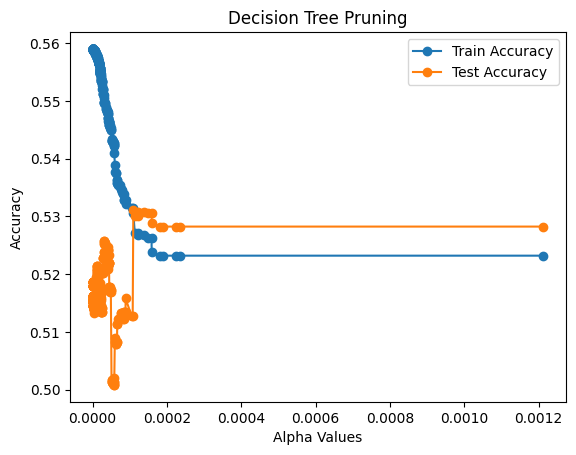

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(ccp_alphas, train_scores, marker='o', label="Train Accuracy")
plt.plot(ccp_alphas, test_scores, marker='o', label="Test Accuracy")

plt.xlabel("Alpha Values")
plt.ylabel("Accuracy")
plt.title("Decision Tree Pruning")

plt.legend()

plt.show()

In [ ]:
model = DecisionTreeClassifier(ccp_alpha=0.0002)
model.fit(x_train_vec, y_train)
y_test_pred = model.predict(x_test_vec)
accuracy_score(y_test, y_test_pred)

0.5282267509955493

In [ ]:
new_review = """Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."""
clean_review = text_cleaning(new_review)

vector = avg_w2v(clean_review, w2v_model, 100).reshape(1,-1)

prediction = model.predict(vector)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review


In [ ]:
!pip install tensorflow

In [86]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
df = pd.read_csv("IMDB Dataset.csv", engine="python", on_bad_lines="skip")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
from nltk.stem.porter import PorterStemmer
py=PorterStemmer()

In [62]:
df.drop_duplicates(inplace=True)

In [73]:
df = df.reset_index(drop=True)
df.loc[3537]

,3537
review,"The mission to see the movie ""The Cave"" was a ..."
sentiment,negative


In [74]:
message=df['review']

In [75]:
message

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."
...,...
7077,Maybe I was to young when I saw it. Perhaps I ...
7078,This is one seriously disturbed movie. Even Th...
7079,It's the 1980's and the teenagers are ready to...
7080,What a crazy film!It lasts 12(!) hours and you...


In [76]:
message.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7082 entries, 0 to 7081
Series name: review
Non-Null Count  Dtype 
--------------  ----- 
7082 non-null   object
dtypes: object(1)
memory usage: 55.5+ KB


In [77]:
message.describe()

,review
count,7082
unique,7082
top,What about Dahmer's childhood?- The double her...
freq,1


In [78]:
df.loc[df.duplicated()]

,review,sentiment


In [79]:
y=df['sentiment']
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [80]:
corpos=[]
for sent in range(0,len(message)):
  review1=re.sub("[^a-zA-Z]"," ",message[sent])
  review2=review1.lower()
  review3=review2.split()
  review4=[py.stem(word) for word in review3 if word not in set(stopwords.words("english")) ]
  review5=" ".join(review4)
  corpos.append(review5)

In [81]:
v=max(corpos, key=len)
v1=len(v)
v1

5838

In [104]:
max_index=9000
one_hot_pre=[one_hot(word,max_index) for word in corpos]

In [105]:
extra_size=200
embedded_docs=pad_sequences(one_hot_pre,padding="pre",maxlen=extra_size)

In [106]:
embedded_docs[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0, 3256,
       5280, 4256, 6416, 1359, 6885, 7655, 8783, 4795, 2014, 6660, 6660,
       5053,  127, 2009, 1359, 7148, 8503, 7588, 1783,  460, 8783, 8581,
       1080, 2434, 7176, 3355, 1403,  726, 7176, 5590, 5368, 2139, 4879,
       2596, 1783, 3704, 6567, 3084, 8581, 6660, 6660,  300, 1359, 8104,
       6035, 3903,  211, 3908,  277, 4307, 8360, 4620, 6228,  407, 6906,
       2463, 8441, 7737, 4102, 5592, 3968, 3102, 3368,  802, 2355, 1749,
        407, 4825, 5939, 4361,  848, 5513, 8128, 5272, 3280, 4147, 1943,
       8224, 1854, 6987, 3367, 8829, 3374, 4647, 6598,  456, 6660, 6660,
       6310, 6450, 2064, 4875, 7176, 4685, 6253, 2304, 7176, 7869, 4656,
       1233, 5969, 1000,  824, 4670, 4656, 5201, 4656,  683, 1359, 5281,
       6162, 5053, 6885, 3489, 3749, 2009, 6470, 41

In [107]:
dim=40
model=Sequential()
model.add(Embedding(max_index,dim,input_length=extra_size))
model.add(LSTM(150))
model.add(Dropout(0.3))
model.add(Dense(1,activation="sigmoid"))
model.compile(optimizer='adam',loss="binary_crossentropy",metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [96]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [108]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)   # converts to 0 and 1

In [109]:
x=np.array(embedded_docs)
Y=np.array(y)


In [110]:
x.shape

(7082, 200)

In [111]:
Y.shape

(7082,)

In [112]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,Y,test_size=0.2,random_state=42)

In [114]:
x_train.shape

(5665, 200)

In [113]:
model.fit(x_train,y_train,validation_data=(x_train,y_train),epochs=10,batch_size=100)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.6392 - loss: 0.6236 - val_accuracy: 0.8397 - val_loss: 0.3734
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8590 - loss: 0.3511 - val_accuracy: 0.9255 - val_loss: 0.2107
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9195 - loss: 0.2242 - val_accuracy: 0.9522 - val_loss: 0.1386
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9384 - loss: 0.1697 - val_accuracy: 0.9635 - val_loss: 0.1386
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9650 - loss: 0.1086 - val_accuracy: 0.9829 - val_loss: 0.0654
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9695 - loss: 0.0938 - val_accuracy: 0.9730 - val_loss: 0.1034
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9788 - loss: 0.0721 - val_accuracy: 0.9928 - val_loss: 0.0339
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9892 - loss: 0.0422 - val_accuracy: 0.9958 - v

In [115]:
pre=model.predict(x_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


In [116]:
from sklearn.metrics import confusion_matrix,classification_report

In [122]:
y_pre=np.where(pre>0.7,1,0)

In [123]:
confusion_matrix(y_pre,y_test)

array([[631, 164],
       [100, 522]])